# Hands On

<https://colab.research.google.com/drive/1ki89Bm_zjUJHP77_UXIrmlj0MJJiFAuw#scrollTo=X0Aap_zqpbkH>

In [262]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [263]:
dataset = pd.read_csv('purchase_data.csv')
df = dataset.copy()

# LOAD & OVERVIEW 
print(df.shape) 
print(df.dtypes)
print(df.head())
print(df.isnull().sum())

(263015, 12)
User_ID                         int64
Product_ID                        str
Gender                            str
Age                               str
Occupation                    float64
City_Category                     str
Stay_In_Current_City_Years        str
Marital_Status                float64
Product_Category_1            float64
Product_Category_2            float64
Product_Category_3            float64
Purchase                      float64
dtype: object
   User_ID Product_ID Gender   Age  Occupation City_Category  \
0  1000001  P00069042      F  0-17        10.0             A   
1  1000001  P00248942      F  0-17        10.0             A   
2  1000001  P00087842      F  0-17        10.0             A   
3  1000001  P00085442      F  0-17        10.0             A   
4  1000002  P00285442      M   55+        16.0             C   

  Stay_In_Current_City_Years  Marital_Status  Product_Category_1  \
0                          2             0.0                 3.0

In [264]:
# 2. BASIC PANDAS STATS
print(df.describe())

# Unique values per column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

            User_ID     Occupation  Marital_Status  Product_Category_1  \
count  2.630150e+05  263014.000000   263014.000000       263014.000000   
mean   1.002941e+06       8.083558        0.408685            5.291099   
std    2.593126e+03       6.524052        0.491592            3.745722   
min    1.000000e+01       0.000000        0.000000            1.000000   
25%    1.001457e+06       2.000000        0.000000            1.000000   
50%    1.002972e+06       7.000000        0.000000            5.000000   
75%    1.004335e+06      14.000000        1.000000            8.000000   
max    1.006040e+06      20.000000        1.000000           18.000000   

       Product_Category_2  Product_Category_3       Purchase  
count       181501.000000        80582.000000  263014.000000  
mean             9.844756           12.658298    9319.305269  
std              5.086696            4.129156    4970.152966  
min              2.000000            3.000000     185.000000  
25%              5

In [265]:
# User_ID                       int64 -> 
# Product_ID                      str -> 
# Gender                          str -> 
# Age                             str -> 
# Occupation                  float64 -> 
# City_Category                   str -> 
# Stay_In_Current_City_Years      str -> 
# Marital_Status              float64 -> 
# Product_Category_1          float64 -> 
# Product_Category_2          float64 -> 
# Product_Category_3          float64 -> 
# Purchase                    float64 -> 

In [266]:
# EDA (Exploratory Data Analysis) -> Analyse the data / understand the pattern
    # Detect the null values
    # Detect the duplicates
    # Detect the Outliers
    # Finding Trends in the data

#Data Preprocessing -> Process the data to make it eligible for building a ml model
    # Handle the null values
    # Handle the duplicates
    # Handle the Outliers
    # Encoding (Object > Numeric)

In [267]:
df['Stay_In_Current_City_Years'].value_counts()

# if a person stay for 4 years or more, it will be 4+
# Convert 4+ to 4 -> numeric

Stay_In_Current_City_Years
1     92588
2     48580
3     45569
4+    40665
0     35612
Name: count, dtype: int64

In [268]:
# Check NaN count
print(df['Stay_In_Current_City_Years'].isnull().sum())

1


In [269]:
# Replace '4+' with '4'
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].replace('4+', '4')

In [270]:
# convert to int
df['Stay_In_Current_City_Years'] = pd.to_numeric(df['Stay_In_Current_City_Years'], errors="coerce")

In [271]:
print(df['Stay_In_Current_City_Years'].dtype)

float64


In [272]:
# Total nulls per column
print(df.isnull().sum())

User_ID                            0
Product_ID                         1
Gender                             1
Age                                1
Occupation                         1
City_Category                      1
Stay_In_Current_City_Years         1
Marital_Status                     1
Product_Category_1                 1
Product_Category_2             81514
Product_Category_3            182433
Purchase                           1
dtype: int64


In [273]:
df['Product_Category_2'] = df['Product_Category_2'].fillna(0)
df['Product_Category_3'] = df['Product_Category_3'].fillna(0)

In [274]:
print(df['Product_Category_2'].isnull().sum())
print(df['Product_Category_3'].isnull().sum())

0
0


In [275]:
# Null count of each column
print(df.isnull().sum())

User_ID                       0
Product_ID                    1
Gender                        1
Age                           1
Occupation                    1
City_Category                 1
Stay_In_Current_City_Years    1
Marital_Status                1
Product_Category_1            1
Product_Category_2            0
Product_Category_3            0
Purchase                      1
dtype: int64


In [276]:
# Null count of each Row
print(df.isnull().sum(axis=1))

0         0
1         0
2         0
3         0
4         0
         ..
263010    0
263011    0
263012    0
263013    0
263014    9
Length: 263015, dtype: int64


In [277]:
# Filter rows that have at least 1 null value
nullRows = df[df.isnull().any(axis=1)]

print(len(nullRows))
print(nullRows)

1
        User_ID Product_ID Gender  Age  Occupation City_Category  \
263014       10        NaN    NaN  NaN         NaN           NaN   

        Stay_In_Current_City_Years  Marital_Status  Product_Category_1  \
263014                         NaN             NaN                 NaN   

        Product_Category_2  Product_Category_3  Purchase  
263014                 0.0                 0.0       NaN  


In [278]:
df.dropna(inplace=True)

In [279]:
df.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64

In [280]:
# Duplicates ->

df.duplicated().sum()

np.int64(0)

In [281]:
# Highest and Lowest values of key columns
cols = ['Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'Purchase']

for col in cols:
    print(f"{col}")
    print(f"  Highest : {df[col].max()}")
    print(f"  Lowest  : {df[col].min()}")
    print()

Product_Category_1
  Highest : 18.0
  Lowest  : 1.0

Product_Category_2
  Highest : 18.0
  Lowest  : 0.0

Product_Category_3
  Highest : 18.0
  Lowest  : 0.0

Purchase
  Highest : 23961.0
  Lowest  : 185.0



In [282]:
# print highest and lowest values for all the columns

print(df.agg(['min', 'max']))

     User_ID Product_ID Gender   Age  Occupation City_Category  \
min  1000001  P00000142      F  0-17         0.0             A   
max  1006040   P0099942      M   55+        20.0             C   

     Stay_In_Current_City_Years  Marital_Status  Product_Category_1  \
min                         0.0             0.0                 1.0   
max                         4.0             1.0                18.0   

     Product_Category_2  Product_Category_3  Purchase  
min                 0.0                 0.0     185.0  
max                18.0                18.0   23961.0  


In [283]:
# OUTLIER DETECTION 
# just IQR bounds + count

Q1 = df['Purchase'].quantile(0.25)
Q3 = df['Purchase'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Purchase'] < lower) | (df['Purchase'] > upper)]

print(f"Lower Bound : {lower}")
print(f"Upper Bound : {upper}")
print(f"Outliers    : {len(outliers)}")

Lower Bound : -3431.0
Upper Bound : 21353.0
Outliers    : 1289


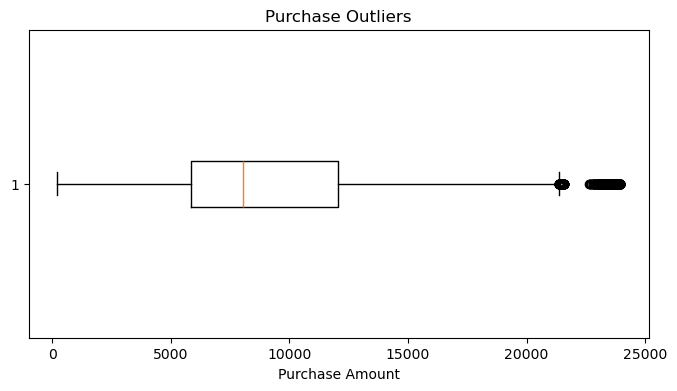

In [284]:
plt.figure(figsize=(8, 4))
plt.boxplot(df['Purchase'], vert=False)
plt.title('Purchase Outliers')
plt.xlabel('Purchase Amount')
plt.show()

## Easy Way

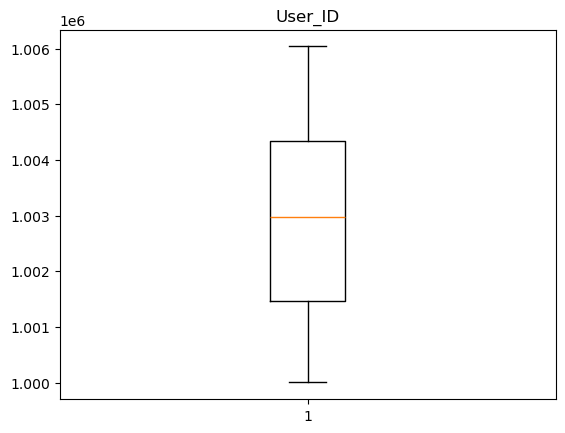

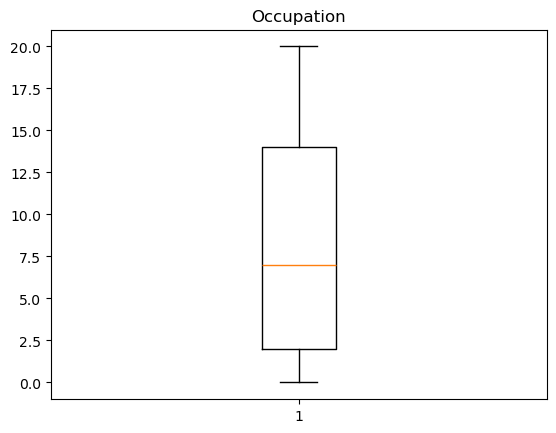

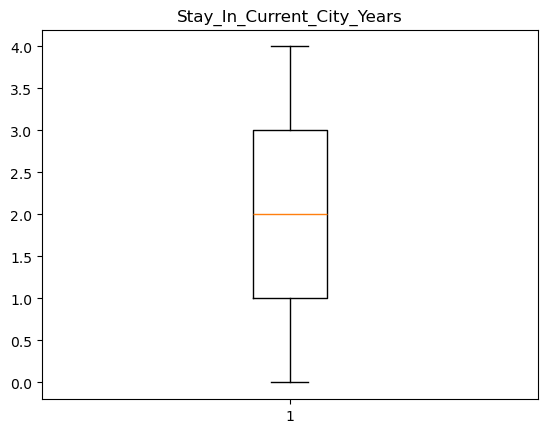

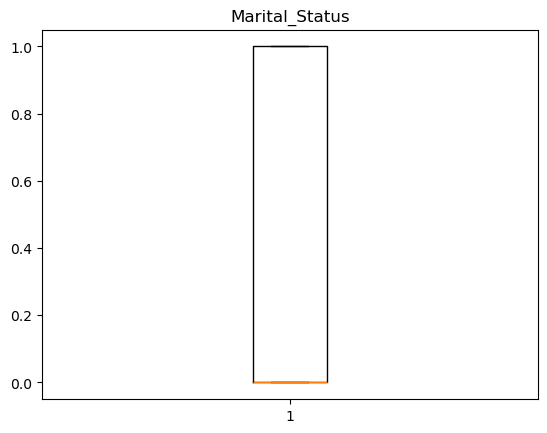

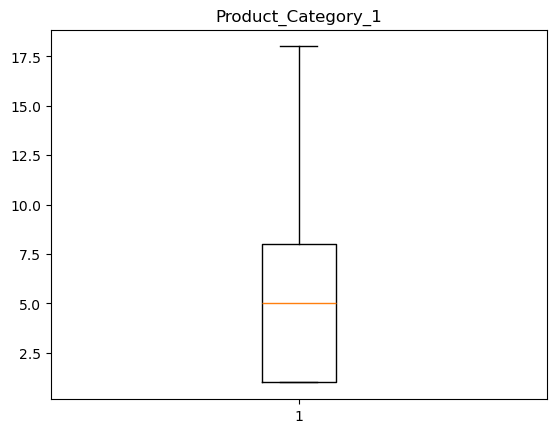

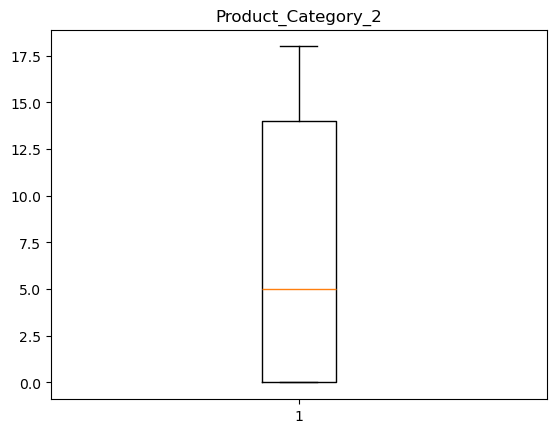

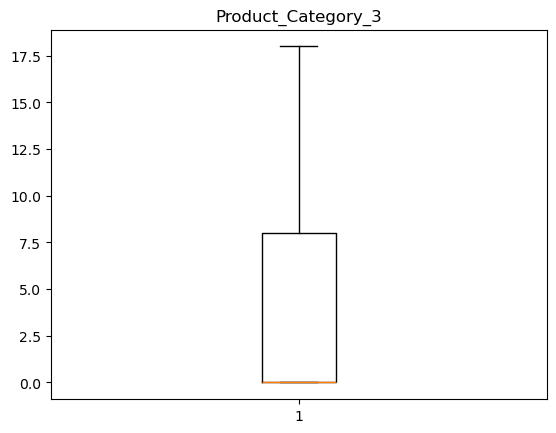

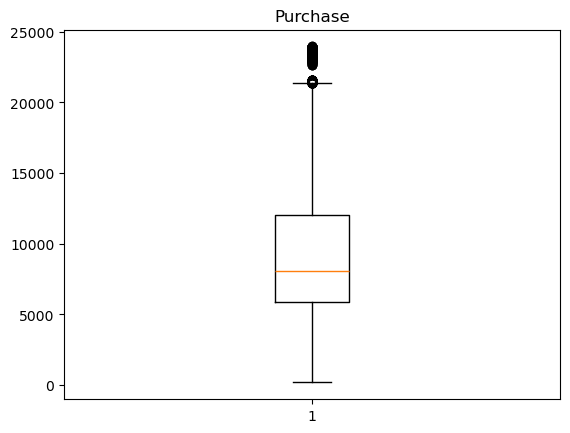

In [285]:
for i in df.columns:
    if df[i].dtype != 'str':
        plt.boxplot(df[i])
        plt.title(i)
        plt.show()

In [286]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 263014 entries, 0 to 263013
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     263014 non-null  int64  
 1   Product_ID                  263014 non-null  str    
 2   Gender                      263014 non-null  str    
 3   Age                         263014 non-null  str    
 4   Occupation                  263014 non-null  float64
 5   City_Category               263014 non-null  str    
 6   Stay_In_Current_City_Years  263014 non-null  float64
 7   Marital_Status              263014 non-null  float64
 8   Product_Category_1          263014 non-null  float64
 9   Product_Category_2          263014 non-null  float64
 10  Product_Category_3          263014 non-null  float64
 11  Purchase                    263014 non-null  float64
dtypes: float64(7), int64(1), str(4)
memory usage: 24.1 MB


In [287]:
from sklearn.preprocessing import LabelEncoder

In [288]:
le = LabelEncoder()

| Method | What it does |
|---|---|
| `fit()` | Learns the data (finds categories, min/max etc.) — doesn't change data |
| `transform()` | Applies the transformation using what it learned |
| `fit_transform()` | Does both in one step — learn + apply |

In [289]:
# fit() learns that Gender has ['F', 'M']
# le.fit(df['Gender'])

# transform() converts F→0, M→1
# le.transform(df['Gender'])

# fit_transform() does both at once
# le.fit_transform(df['Gender'])

In [290]:
# before converting create dictionary to keep track

In [291]:
# Store mappings of all encoded columns
empty_dict = {}

for i in df.columns:
    if(df[i].dtype == "str"):
        df[i] = le.fit_transform(df[i])
        empty_dict[i] = dict(zip(le.classes_, le.transform(le.classes_)))

In [292]:
# Check the mappings
for col, mapping in empty_dict.items():
    print(f"{col}: {mapping}")

Product_ID: {'P00000142': np.int64(0), 'P00000242': np.int64(1), 'P00000342': np.int64(2), 'P00000442': np.int64(3), 'P00000542': np.int64(4), 'P00000642': np.int64(5), 'P00000742': np.int64(6), 'P00000842': np.int64(7), 'P00000942': np.int64(8), 'P00001042': np.int64(9), 'P00001142': np.int64(10), 'P00001242': np.int64(11), 'P00001342': np.int64(12), 'P00001442': np.int64(13), 'P00001542': np.int64(14), 'P00001642': np.int64(15), 'P00001742': np.int64(16), 'P00001842': np.int64(17), 'P00001942': np.int64(18), 'P00002042': np.int64(19), 'P00002142': np.int64(20), 'P00002242': np.int64(21), 'P00002342': np.int64(22), 'P00002442': np.int64(23), 'P00002542': np.int64(24), 'P00002642': np.int64(25), 'P00002742': np.int64(26), 'P00002842': np.int64(27), 'P00002942': np.int64(28), 'P00003042': np.int64(29), 'P00003142': np.int64(30), 'P00003242': np.int64(31), 'P00003342': np.int64(32), 'P00003442': np.int64(33), 'P00003542': np.int64(34), 'P00003642': np.int64(35), 'P00003742': np.int64(36)

In [293]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 263014 entries, 0 to 263013
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     263014 non-null  int64  
 1   Product_ID                  263014 non-null  int64  
 2   Gender                      263014 non-null  int64  
 3   Age                         263014 non-null  int64  
 4   Occupation                  263014 non-null  float64
 5   City_Category               263014 non-null  int64  
 6   Stay_In_Current_City_Years  263014 non-null  float64
 7   Marital_Status              263014 non-null  float64
 8   Product_Category_1          263014 non-null  float64
 9   Product_Category_2          263014 non-null  float64
 10  Product_Category_3          263014 non-null  float64
 11  Purchase                    263014 non-null  float64
dtypes: float64(7), int64(5)
memory usage: 24.1 MB


---

In [295]:
# Statistical Analysis ->

# Step 1 -> Data Collection
# Step 2 -> Prepare Sample
# Step 3 -> Creating two Hypothesis (Null Hypothesis(H0), Alternate Hypothesis(H1/HA))
# Step 4 -> Decide which test to apply and apply the test
# Step 5 -> Check p_value -> Reject the Null OR Failed to reject the null

In [294]:
# it was observed that the average purchase made by the men of age group of 18 to 25 was 1000
# It is still the same?

In [297]:
new_df = df[(df['Gender']==1) & (df['Age']==1)]
new_df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
97,1000021,2024,1,1,16.0,1,0.0,0.0,3.0,12.0,0.0,3055.0
98,1000022,3261,1,1,15.0,0,4.0,0.0,1.0,8.0,17.0,12099.0
99,1000022,1954,1,1,15.0,0,4.0,0.0,5.0,8.0,0.0,8797.0
100,1000022,1792,1,1,15.0,0,4.0,0.0,3.0,4.0,0.0,10681.0
101,1000022,1020,1,1,15.0,0,4.0,0.0,8.0,14.0,0.0,7801.0
...,...,...,...,...,...,...,...,...,...,...,...,...
262767,1004446,1311,1,1,18.0,1,1.0,1.0,1.0,2.0,0.0,15431.0
262951,1004465,2880,1,1,4.0,0,1.0,1.0,5.0,0.0,0.0,1763.0
262952,1004465,1296,1,1,4.0,0,1.0,1.0,2.0,3.0,4.0,3240.0
262953,1004465,2733,1,1,4.0,0,1.0,1.0,8.0,0.0,0.0,5832.0


In [ ]:
# Sample -> 10% of our overall data

In [315]:
sample = new_df.sample(3600, random_state = 42) 
# random_state is a fixed seed, otherwise sample dataset will change in every execution

sample

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
205154,1001647,1799,1,1,18.0,1,0.0,0.0,8.0,14.0,0.0,5831.0
153395,1005709,20,1,1,4.0,1,4.0,0.0,1.0,5.0,8.0,19455.0
23439,1003653,2326,1,1,15.0,2,3.0,1.0,5.0,11.0,0.0,8893.0
258890,1003868,2058,1,1,12.0,2,0.0,0.0,11.0,15.0,0.0,3151.0
251998,1002896,2493,1,1,14.0,1,0.0,0.0,8.0,17.0,0.0,5933.0
...,...,...,...,...,...,...,...,...,...,...,...,...
99763,1003471,2381,1,1,4.0,0,1.0,0.0,5.0,0.0,0.0,5221.0
240739,1001137,2050,1,1,4.0,1,4.0,0.0,8.0,0.0,0.0,8059.0
208800,1002127,1135,1,1,4.0,2,0.0,1.0,1.0,16.0,0.0,11628.0
225640,1004761,2461,1,1,15.0,2,1.0,0.0,5.0,8.0,0.0,8565.0


In [ ]:
# Null Hypothesis -> The avg purchase is still 10000

# Alternate Hypothesis -> The avg purchase is not 10000

In [ ]:
# One sample t-test
# comparing sample mean against known value 1000

In [313]:
from scipy import stats

In [326]:
t_stat, p_value = stats.ttest_1samp(sample['Purchase'], 10000)

print(f"Sample Mean : {sample['Purchase'].mean():.2f}")
print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")

# Conclusion
if p_value < 0.05:
    print("Reject H0 → Average purchase is NOT 1000 anymore")
else:
    print("Fail to Reject H0 → Average purchase is still ~1000")

Sample Mean : 9332.71
T-Statistic : -8.0319
P-Value     : 0.0000
Reject H0 → Average purchase is NOT 1000 anymore


## OR

In [320]:
from scipy.stats import ttest_1samp

In [321]:
pop_mean = 10000

In [322]:
t_stats, p_value = ttest_1samp(sample['Purchase'], pop_mean)

In [323]:
p_value

np.float64(1.2879087768827263e-15)

In [325]:
if (p_value < 0.05):
    print("Reject the Null")
else:
    print("Failed to Reject the Null")

Reject the Null


---

In [ ]:
# Is the Average purchase made by men and women of age group 18 to 25 are same?

In [328]:
# Collect the data
male_df   = df[df['Gender'] == empty_dict['Gender']['M']]
female_df = df[df['Gender'] == empty_dict['Gender']['F']]

# Sample
male_sample   = male_df[male_df['Age'] == empty_dict['Age']['18-25']]
female_sample = female_df[female_df['Age'] == empty_dict['Age']['18-25']]

# Test
t_stats, p_value = stats.ttest_ind(male_sample['Purchase'], female_sample['Purchase'])

print(p_value)

if p_value < 0.05:
    print("Reject the Null")
else:
    print("Failed to Reject the Null")

1.3766463657735171e-86
Reject the Null
